# Waterfall Build-up — Incremental Component Analysis

This notebook visualises the Pareto front progression as the algorithmic pipeline grows from:

1. Random Search
2. MOEA/D + GA
3. MOEA/D + GA + PSO
4. MOEA/D + GA + PSO + SA

All four runs use **seed=42**, **budget=2000 NFE**, **hardware=edgegpu_latency**, **dataset=cifar10**.

In [21]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

from src.analysis.pareto_metrics import (
    archive_to_points,
    get_pareto_front,
    calc_hv,
    calc_igd,
)

RESULTS_DIR = PROJECT_ROOT / "results" / "incremental"
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
sns.set_style("whitegrid")

STAGES = [
    ("stage1_random.json",       "Stage 1: Random",            "#aec6e8"),
    ("stage2_moead_ga.json",     "Stage 2: +MOEA/D + GA",      "#4a90d9"),
    ("stage3_moead_ga_pso.json", "Stage 3: +PSO",              "#1a4f8a"),
    ("stage4_full.json",         "Stage 4: +SA (Full)",        "#f4a636"),
]
REF = np.array([1.1, 1.1])

In [22]:
def load_archive(fname: str) -> list[dict]:
    path = RESULTS_DIR / fname
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. Run: python scripts/run_incremental_build.py --seed 42"
        )
    payload = json.loads(path.read_text())
    return payload["archive"]


def to_display(front: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    acc = -front[:, 0]
    lat = front[:, 1]
    order = np.argsort(acc)
    return acc[order], lat[order]


stages_data = []
archives = []
for fname, label, color in STAGES:
    archive = load_archive(fname)
    pts = archive_to_points(archive)
    front = get_pareto_front(pts)
    archives.append(archive)
    acc, lat = to_display(front)
    stages_data.append({
        "label": label,
        "color": color,
        "archive": archive,
        "front": front,
        "acc": acc,
        "lat": lat,
    })
    print(f"{label}: {len(acc)} Pareto points | acc=[{acc.min():.2f}, {acc.max():.2f}] | lat=[{lat.min():.2f}, {lat.max():.2f}]")

all_points = np.vstack([get_pareto_front(archive_to_points(a)) for a in archives])
proxy_front = get_pareto_front(all_points)
min_val = all_points.min(axis=0)
max_val = all_points.max(axis=0)
scale = np.where(max_val - min_val > 0, max_val - min_val, 1.0)


def normalise(points: np.ndarray) -> np.ndarray:
    return (points - min_val) / scale

proxy_norm = normalise(proxy_front)

stage_metrics = []
for stage in stages_data:
    norm_front = normalise(stage["front"])
    hv = calc_hv(norm_front, ref_point=REF)
    igd = calc_igd(norm_front, proxy_norm)
    best_acc_lt2 = float(stage["acc"][stage["lat"] < 2.0].max()) if np.any(stage["lat"] < 2.0) else np.nan
    best_lat_gt90 = float(stage["lat"][stage["acc"] > 90.0].min()) if np.any(stage["acc"] > 90.0) else np.nan
    stage_metrics.append({
        "Stage": stage["label"],
        "HV": hv,
        "IGD": igd,
        "Best Accuracy @ Latency < 2ms": best_acc_lt2,
        "Best Latency @ Accuracy > 90%": best_lat_gt90,
        "Pareto Points": len(stage["acc"]),
    })

metrics_df = pd.DataFrame(stage_metrics)
metrics_df["ΔHV"] = metrics_df["HV"].diff().fillna(0.0)
metrics_df["ΔIGD Improvement"] = (-metrics_df["IGD"].diff()).fillna(0.0)

metrics_df

Stage 1: Random: 13 Pareto points | acc=[10.00, 94.22] | lat=[0.54, 6.86]
Stage 2: +MOEA/D + GA: 144 Pareto points | acc=[10.00, 94.25] | lat=[0.54, 6.50]
Stage 3: +PSO: 108 Pareto points | acc=[10.00, 94.36] | lat=[0.50, 7.05]
Stage 4: +SA (Full): 293 Pareto points | acc=[10.00, 94.37] | lat=[0.50, 6.81]


,Stage,HV,IGD,Best Accuracy @ Latency < 2ms,Best Latency @ Accuracy > 90%,Pareto Points,ΔHV,ΔIGD Improvement
0,Stage 1: Random,1.054370,0.004809,92.276665,1.754365,13,0.000000,0.000000
1,Stage 2: +MOEA/D + GA,1.054952,0.004923,92.245003,1.738467,144,0.000583,-0.000114
2,Stage 3: +PSO,1.053812,0.004919,92.190002,1.738467,108,-0.001140,0.000004
3,Stage 4: +SA (Full),1.055057,0.000371,92.504997,1.764450,293,0.001244,0.004549


Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/incremental/waterfall_pareto_overlay.pdf


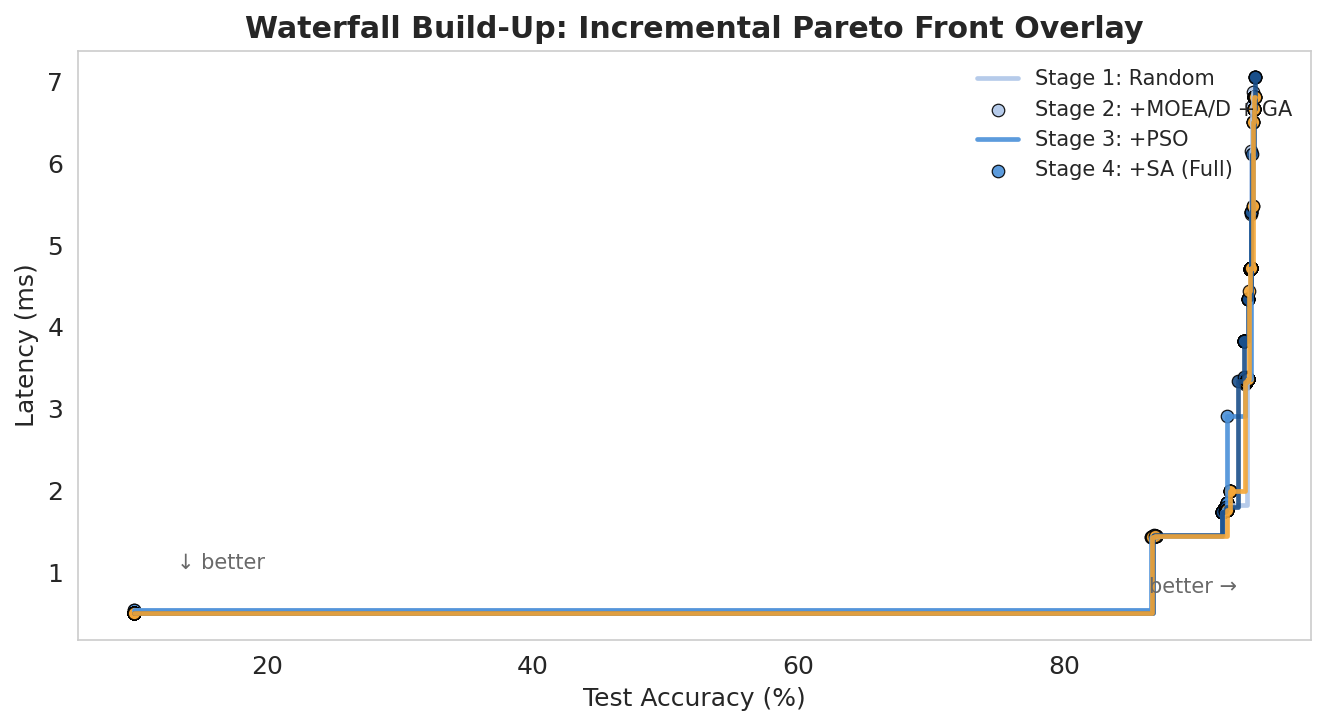

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/incremental/stage_hv_progression.pdf


/tmp/ipykernel_29412/1469533677.py:38: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig2.tight_layout()


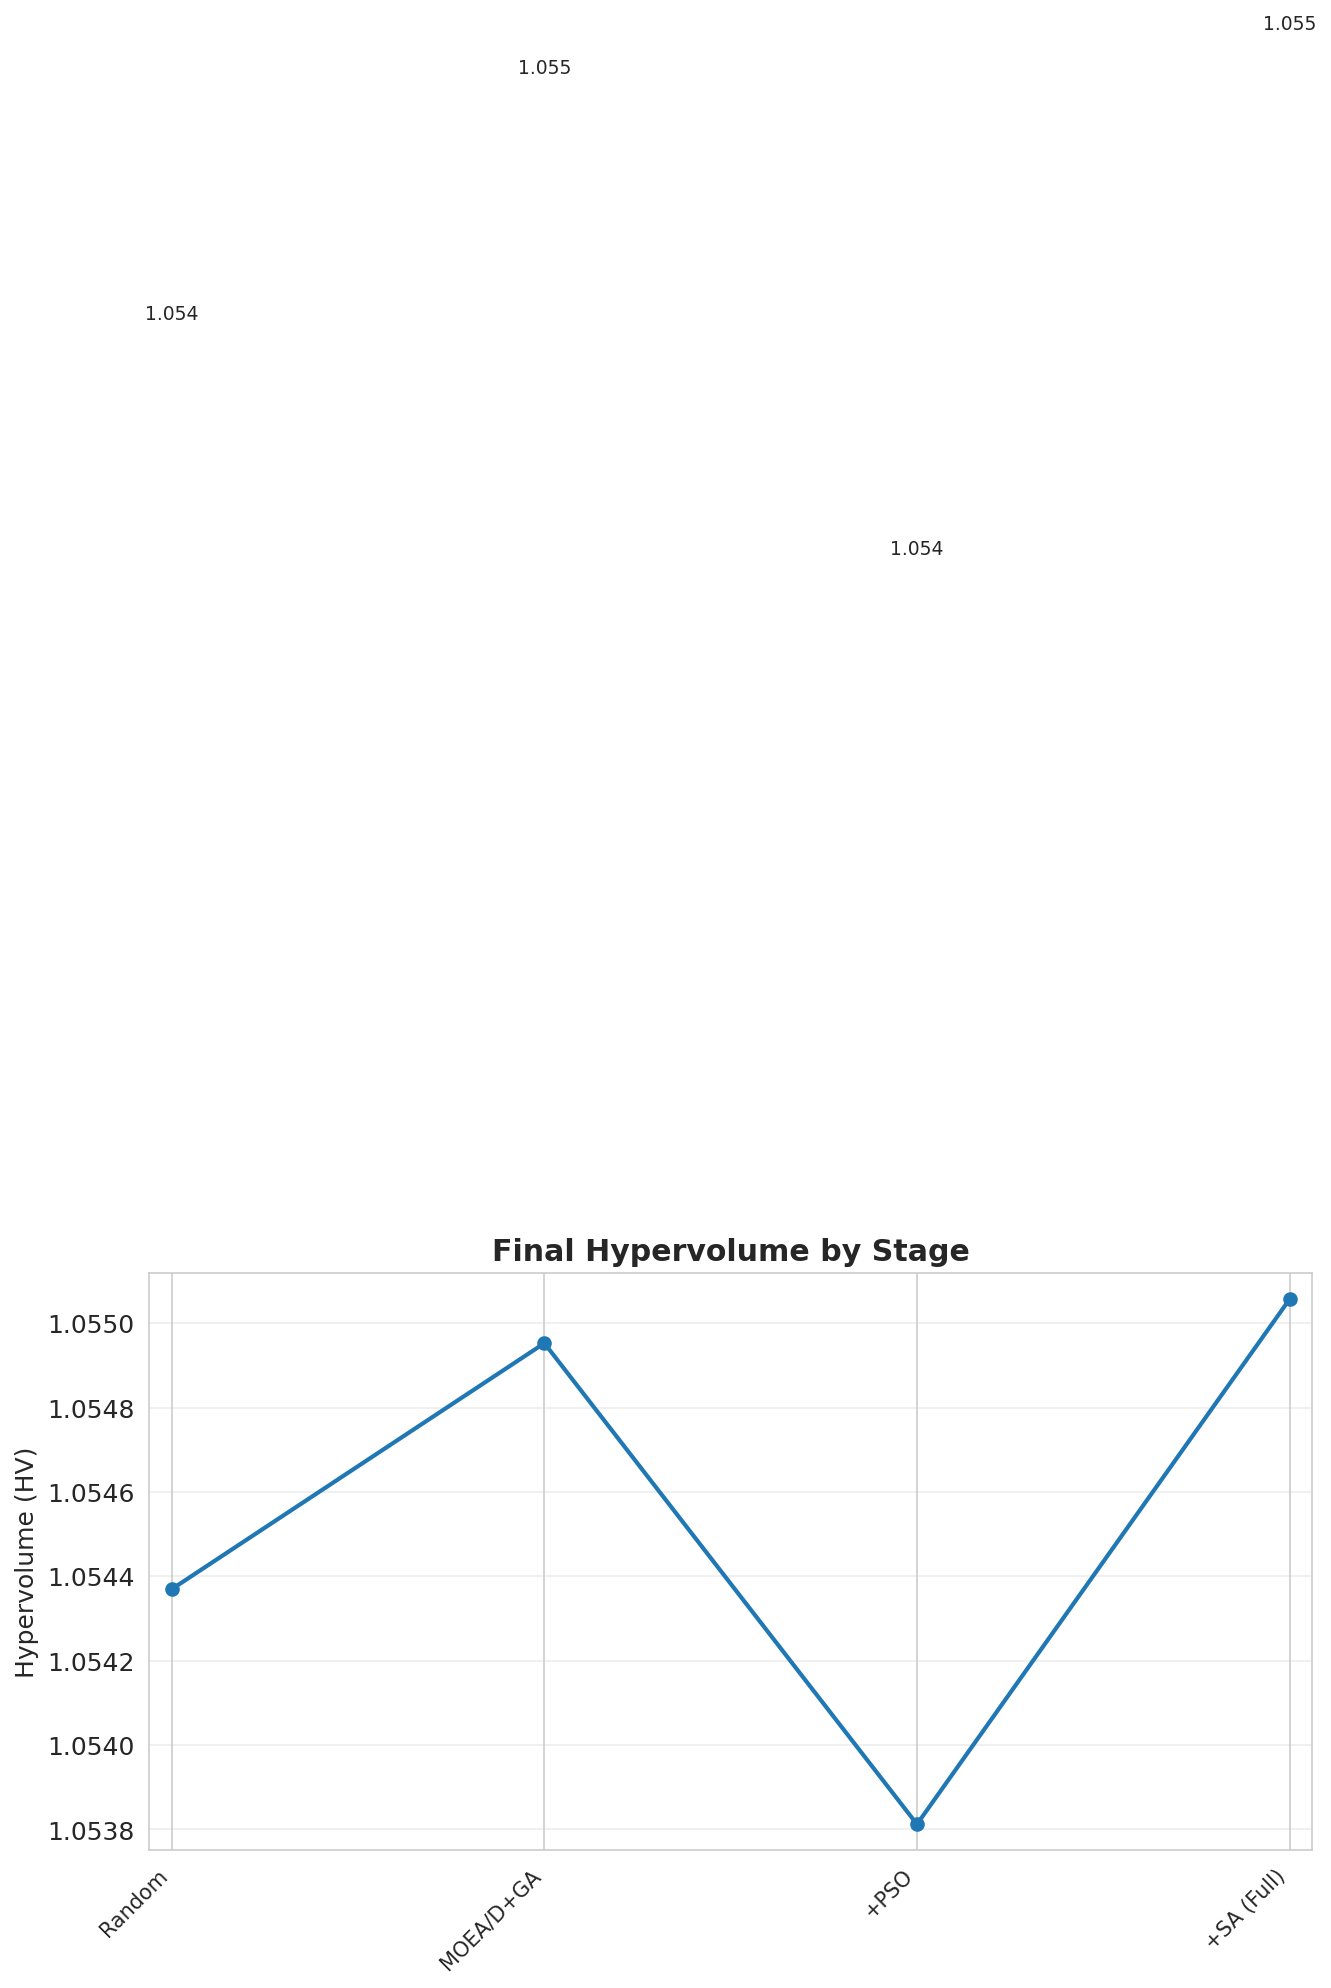

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/incremental/stage_igd_progression.pdf


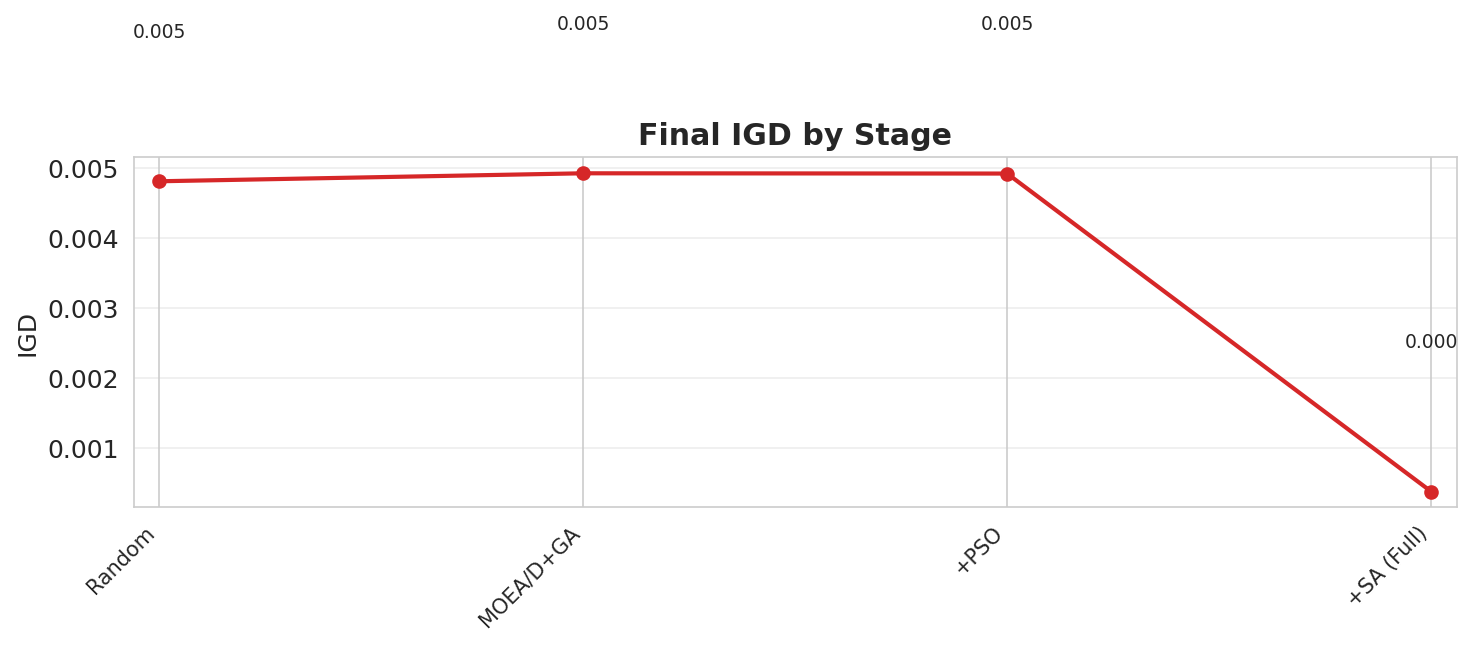

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/incremental/stage_delta_improvements.pdf


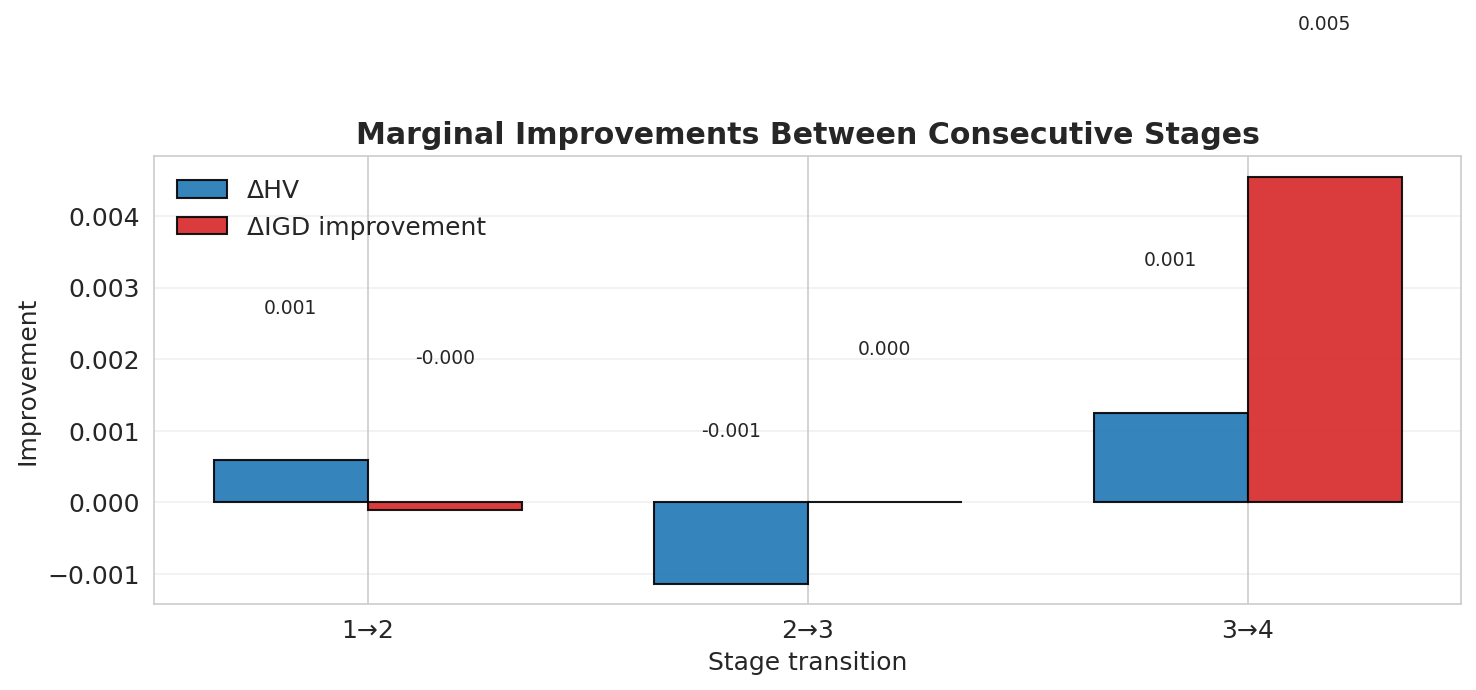

Saved → /home/abdeslem/Folders/2CS/S2/PROJ/HW-NAS-Memetic/results/incremental/stage_scalar_summary.pdf


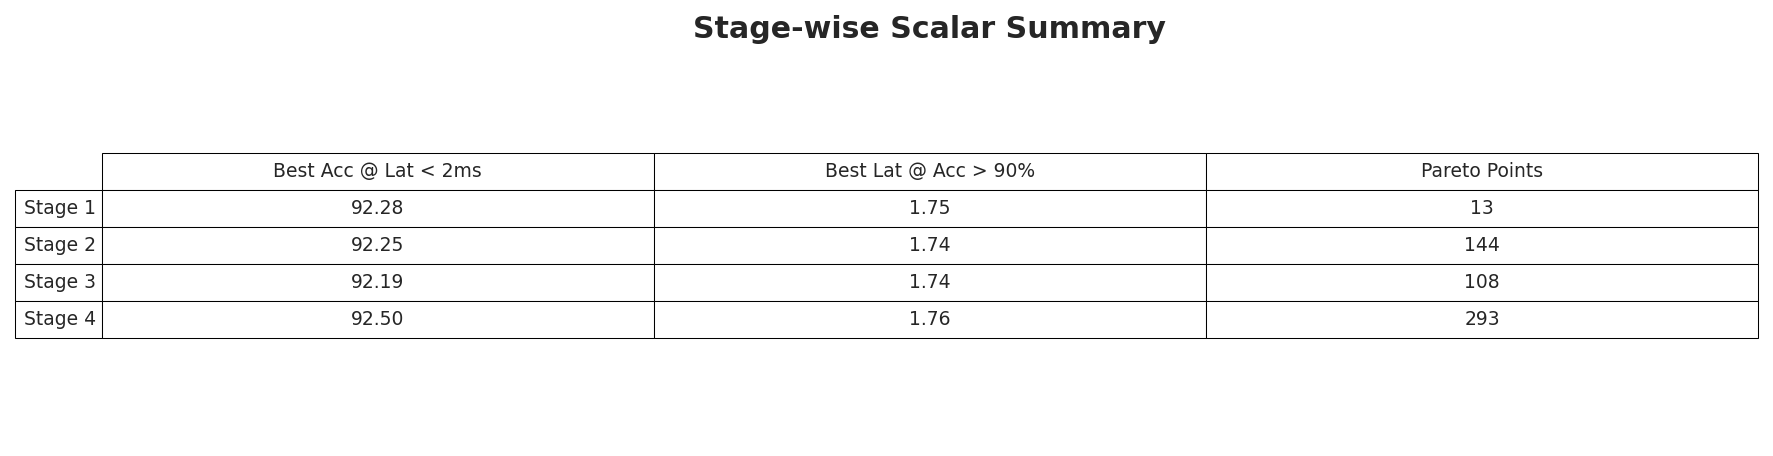

In [23]:
fig, ax = plt.subplots(figsize=(9, 5))
for stage in stages_data:
    ax.step(stage["acc"], stage["lat"], where="post", color=stage["color"], linewidth=2.25, alpha=0.9)
    ax.scatter(stage["acc"], stage["lat"], color=stage["color"], s=36, edgecolors="black", linewidth=0.6, alpha=0.9)

ax.set_xlabel("Test Accuracy (%)")
ax.set_ylabel("Latency (ms)")
ax.set_title("Waterfall Build-Up: Incremental Pareto Front Overlay", fontweight="bold")
ax.legend([stage["label"] for stage in stages_data], frameon=False, fontsize=10, loc="upper right")
ax.annotate("better →", xy=(0.94, 0.08), xycoords="axes fraction", ha="right", fontsize=10, color="dimgray")
ax.annotate("↓ better", xy=(0.08, 0.12), xycoords="axes fraction", ha="left", fontsize=10, color="dimgray")
ax.grid(False)

fig.tight_layout()
out_path = PROJECT_ROOT / "results" / "incremental" / "waterfall_pareto_overlay.pdf"
fig.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

stage_labels = [
    "Random",
    "MOEA/D+GA",
    "+PSO",
    "+SA (Full)",
]
fig2, ax2 = plt.subplots(figsize=(10, 5))
ax2.plot(stage_labels, metrics_df["HV"], marker="o", linewidth=2.0, color="#1f77b4")
ax2.set_title("Final Hypervolume by Stage", fontweight="bold")
ax2.set_xlabel("")
ax2.set_ylabel("Hypervolume (HV)")
ax2.grid(axis="y", alpha=0.35)
ax2.set_xticks(stage_labels)
ax2.set_xticklabels(stage_labels, rotation=45, ha="right", fontsize=10)
ax2.tick_params(axis="x", labelsize=10)
ax2.margins(x=0.02)
for x, y in zip(stage_labels, metrics_df["HV"]):
    ax2.text(x, y + 0.003, f"{y:.3f}", ha="center", va="bottom", fontsize=9)
fig2.tight_layout()
out_path = PROJECT_ROOT / "results" / "incremental" / "stage_hv_progression.pdf"
fig2.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

fig3, ax3 = plt.subplots(figsize=(10, 5))
ax3.plot(stage_labels, metrics_df["IGD"], marker="o", linewidth=2.0, color="#d62728")
ax3.set_title("Final IGD by Stage", fontweight="bold")
ax3.set_xlabel("")
ax3.set_ylabel("IGD")
ax3.grid(axis="y", alpha=0.35)
ax3.set_xticks(stage_labels)
ax3.set_xticklabels(stage_labels, rotation=45, ha="right", fontsize=10)
ax3.tick_params(axis="x", labelsize=10)
ax3.margins(x=0.02)
for x, y in zip(stage_labels, metrics_df["IGD"]):
    ax3.text(x, y + 0.002, f"{y:.3f}", ha="center", va="bottom", fontsize=9)
fig3.tight_layout()
out_path = PROJECT_ROOT / "results" / "incremental" / "stage_igd_progression.pdf"
fig3.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

fig4, ax4 = plt.subplots(figsize=(10, 5))
indices = np.arange(1, len(metrics_df))
width = 0.35
ax4.bar(indices - width / 2, metrics_df["ΔHV"][1:], width, label="ΔHV", color="#1f77b4", edgecolor="black", alpha=0.9)
ax4.bar(indices + width / 2, metrics_df["ΔIGD Improvement"][1:], width, label="ΔIGD improvement", color="#d62728", edgecolor="black", alpha=0.9)
ax4.set_xticks(indices)
ax4.set_xticklabels(["1→2", "2→3", "3→4"])
ax4.set_title("Marginal Improvements Between Consecutive Stages", fontweight="bold")
ax4.set_xlabel("Stage transition")
ax4.set_ylabel("Improvement")
ax4.legend(frameon=False)
ax4.grid(axis="y", alpha=0.3)
for i, (dhv, digd) in enumerate(zip(metrics_df["ΔHV"][1:], metrics_df["ΔIGD Improvement"][1:]), start=1):
    ax4.text(i - width / 2, dhv + 0.002, f"{dhv:.3f}", ha="center", va="bottom", fontsize=9)
    ax4.text(i + width / 2, digd + 0.002, f"{digd:.3f}", ha="center", va="bottom", fontsize=9)
fig4.tight_layout()
out_path = PROJECT_ROOT / "results" / "incremental" / "stage_delta_improvements.pdf"
fig4.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()

fig5, ax5 = plt.subplots(figsize=(12, 3.2))
ax5.axis("off")
cell_text = []
for _, row in metrics_df.iterrows():
    cell_text.append([
        f"{row['Best Accuracy @ Latency < 2ms']:.2f}" if not np.isnan(row['Best Accuracy @ Latency < 2ms']) else "n/a",
        f"{row['Best Latency @ Accuracy > 90%']:.2f}" if not np.isnan(row['Best Latency @ Accuracy > 90%']) else "n/a",
        f"{int(row['Pareto Points'])}",
    ])
short_stage_labels = ["Stage 1", "Stage 2", "Stage 3", "Stage 4"]

col_labels = [
    "Best Acc @ Lat < 2ms",
    "Best Lat @ Acc > 90%",
    "Pareto Points",
]

table = ax5.table(
    cellText=cell_text,
    colLabels=col_labels,
    rowLabels=short_stage_labels,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.4)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.5)

ax5.set_title("Stage-wise Scalar Summary", fontweight="bold")
fig5.tight_layout()
out_path = PROJECT_ROOT / "results" / "incremental" / "stage_scalar_summary.pdf"
fig5.savefig(out_path, bbox_inches="tight")
print(f"Saved → {out_path}")
plt.show()